# example with Earthmover"

We will use the monthly regrid data for NE Pacific.
https://app.earthmover.io/NOAA-PMEL/cefi-nep-hindcast-monthly/tree/main/regrid/main

## Using ncdf4


In [1]:
library(ncdf4)

### Load all the variables 

We don't need to load a specific nc file.


In [2]:
url <- "https://compute.earthmover.io/v1/services/dap2/NOAA-PMEL/cefi-nep-hindcast-monthly/main/regrid/main/opendap"
nc <- nc_open(url)

Lot's of variables.

In [3]:
names(nc$var)

[1] "FRAZIL"                      "LSRC"                       
  [3] "aragos"                      "bfeos"                      
  [5] "btm_co3_ion"                 "btm_co3_sol_arag"           
  [7] "btm_o2"                      "calcos"                     
  [9] "cased_redis_coef"            "chl"                        
 [11] "chl_Di"                      "chl_Sm"                     
 [13] "chldiazos"                   "MIB"                        
 [15] "bsios"                       "btm_htotal"                 
 [17] "cased"                       "chl_Lg"                     
 [19] "chldiatos"                   "btm_temp"                   
 [21] "chlmiscos"                   "chlpicoos"                  
 [23] "co3os"                       "co3satcalcos"               
 [25] "dep_dry_lith"                "dep_dry_no3"                
 [27] "dep_wet_fed"                 "LSNK"                       
 [29] "cased_redis_delz"            "co3"                        
 [31] "dep_dry_fed"                 "dep_dry_po4"                
 [33] "btm_co3_sol_calc"            "dep_wet_lith"               
 [35] "dep_wet_nh4"                 "dfeos"                      
 [37] "chlos"                       "co3sataragos"               
 [39] "chl_Md"                      "dep_wet_no3"                
 [41] "dep_dry_nh4"                 "dic_deltap"                 
 [43] "dic_sc_no"                   "dissic"                     
 [45] "dissoc"                      "don_100"                    
 [47] "baccos"                      "detocos"                    
 [49] "dic_stf_gas"                 "dissocos"                   
 [51] "dissicos"                    "dic_csurf"                  
 [53] "dpo2"                        "epc100"                     
 [55] "epcalc100"                   "epn100"                     
 [57] "epsi100"                     "fcadet_calc_btm"            
 [59] "fcased_burial"               "dpco2"                      
 [61] "epfe100"                     "fcadet_arag_btm"            
 [63] "dic_kw"                      "epp100"                     
 [65] "eparag100"                   "fcased_redis"               
 [67] "fedet"                       "ffe_sed"                    
 [69] "ffedi_btm"                   "ffemd_btm"                  
 [71] "fcased_redis_surfresp"       "feprime"                    
 [73] "ffelg_btm"                   "fed"                        
 [75] "ffedet_btm"                  "ffetot_btm"                 
 [77] "flithdet_btm"                "fntot_btm"                  
 [79] "fpdet_btm"                   "fpdi_btm"                   
 [81] "fgo2"                        "fndi_btm"                   
 [83] "fnlg_btm"                    "fplg_btm"                   
 [85] "fnmd_btm"                    "fno3denit_sed"              
 [87] "fpmd_btm"                    "fgco2"                      
 [89] "fndet_btm"                   "fnoxic_sed"                 
 [91] "fric"                        "froc"                       
 [93] "fsidet_btm"                  "fsimd_btm"                  
 [95] "fsn"                         "htotal"                     
 [97] "intdic"                      "intpbfe"                    
 [99] "intpbp"                      "fsfe"                       
[101] "fptot_btm"                   "intdoc"                     
[103] "intpbn"                      "intpbsi"                    
[105] "intpn2"                      "intpp"                      
[107] "frn"                         "intppdiaz"                  
[109] "frfe"                        "intppnitrate"               
[111] "irr_inst"                    "irrlim_Di"                  
[113] "irrlim_Md"                   "icfriver"                   
[115] "intpoc"                      "fsilg_btm"                  
[117] "intparag"                    "intppmisc"                  
[119] "irr_mix"                     "irrlim_Sm"                  
[121] "intppdiat"                   "intpp

### Getting all data for surface

All the data for the surface takes about 3 minutes and is 800+ Mb.


In [ ]:
tm <- system.time({
  vo_surface_all <- ncvar_get(
    nc,
    varid = "vo_rotate",
    start = c(1, 1, 1, 1),
    count = c(-1, -1, 1, -1)
  )
  })
tm

In [ ]:
dim(vo_surface_all)
format(object.size(vo_surface_all), units = "MB")

### Getting data for bounding box

CCE domain, all times, 1 depth


In [4]:
lon  <- ncvar_get(nc, "lon")
lat  <- ncvar_get(nc, "lat")

# bounding box
lon_min <- 220
lon_max <- max(lon)
lat_min <- 20
lat_max <- 48

# indices
lon_idx <- which(lon >= lon_min & lon <= lon_max)
lat_idx <- which(lat >= lat_min & lat <= lat_max)

# counts
lon_start <- min(lon_idx)
lon_count <- length(lon_idx)

lat_start <- min(lat_idx)
lat_count <- length(lat_idx)


This takes a minute or so.

In [5]:
tm <- system.time({
  vo_surface_bbox <- ncvar_get(
    nc,
    varid = "vo_rotate",
    start = c(lon_start, lat_start, 1, 1),
    count = c(lon_count, lat_count, 1, -1)
  )
})
tm

   user  system elapsed 
  1.234   0.187  11.620 

In [6]:
dim(vo_surface_bbox)
format(object.size(vo_surface_bbox), units = "MB")

[1] 122 326 390

[1] "118.3 Mb"

## Time series of spatial means

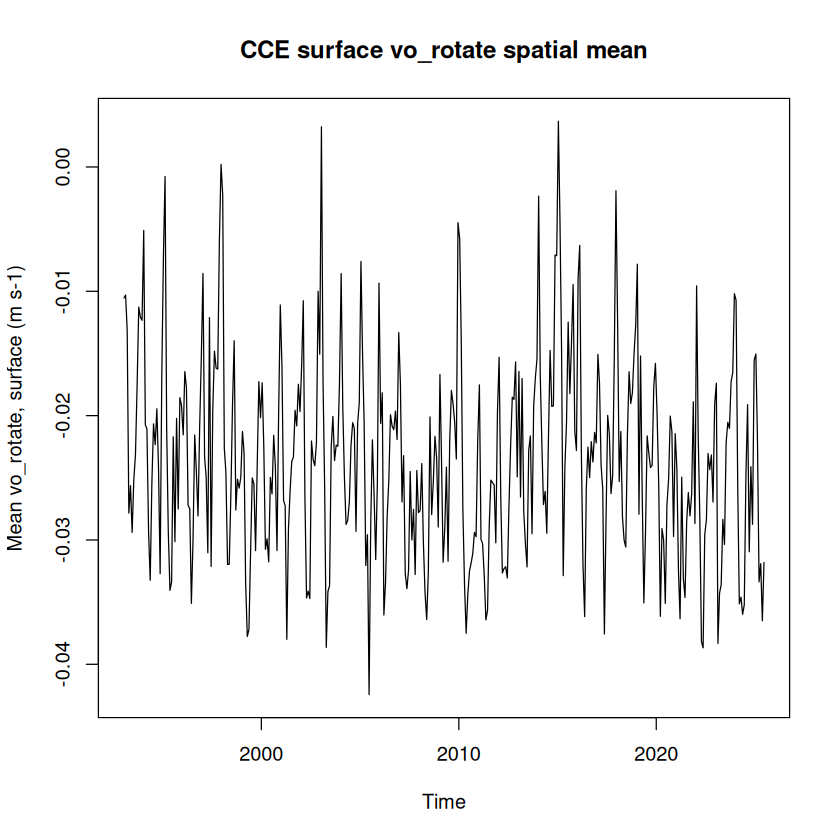

In [7]:
# coordinates for the subset
lon_sub <- lon[lon_start:(lon_start + lon_count - 1)]
lat_sub <- lat[lat_start:(lat_start + lat_count - 1)]

# time values
time_raw <- ncvar_get(nc, "time")
time_units <- ncatt_get(nc, "time", "units")$value
origin <- sub("days since ", "", time_units)
time_dates <- as.Date(time_raw, origin = origin)

# spatial mean for each time slice
vo_mean_ts <- apply(vo_surface_bbox, 3, mean, na.rm = TRUE)

plot(
  time_dates,
  vo_mean_ts,
  type = "l",
  xlab = "Time",
  ylab = "Mean vo_rotate, surface (m s-1)",
  main = "CCE surface vo_rotate spatial mean"
)

### Make a quick plot of first time slice

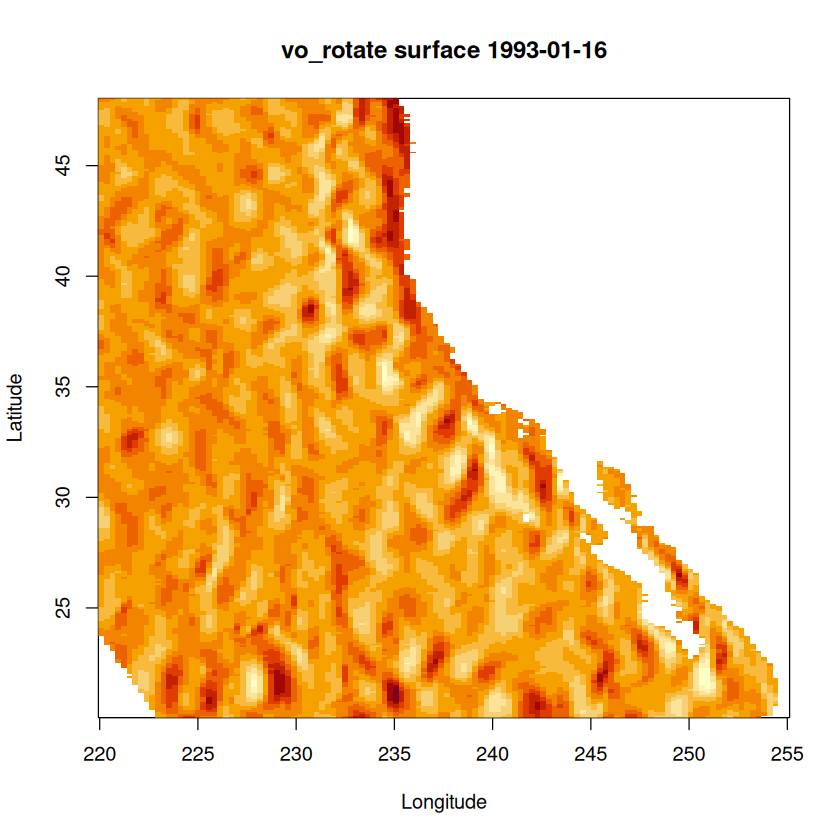

In [8]:
image(
  lon_sub,
  lat_sub,
  vo_surface_bbox[, , 1],
  xlab = "Longitude",
  ylab = "Latitude",
  main = paste("vo_rotate surface", time_dates[1])
)

### Make plot with terra

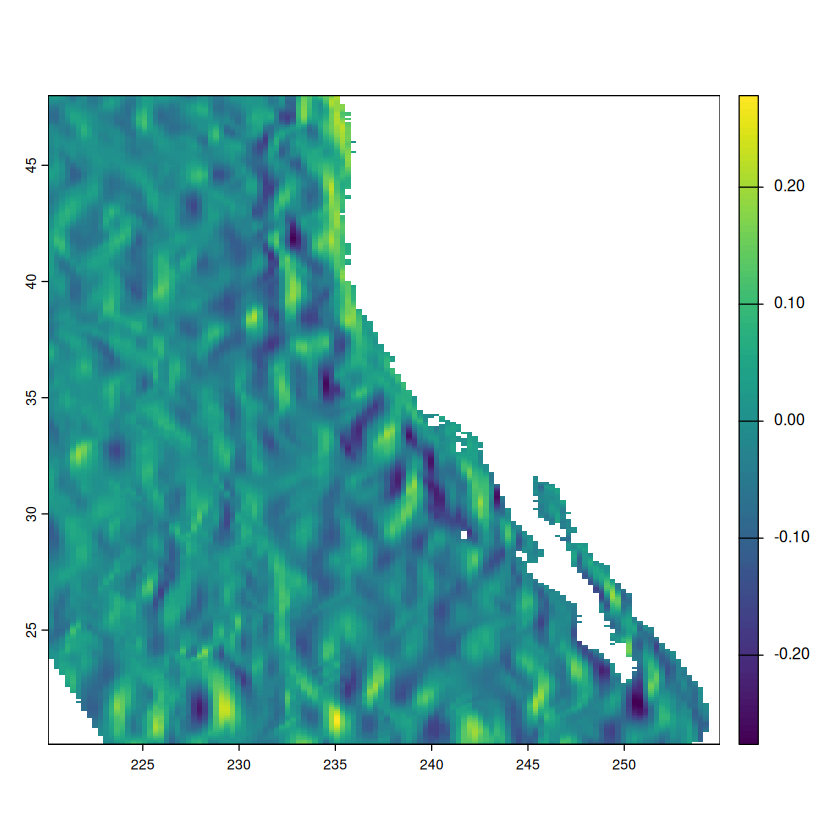

In [10]:
library(terra)
m <- vo_surface_bbox[, , 1]
m_terra <- t(m)

# terra expects first matrix row to be north/top,
# but lat_sub is south-to-north, so flip matrix rows
m_terra <- m_terra[nrow(m_terra):1, ]

r <- rast(
  m_terra,
  extent = ext(min(lon_sub), max(lon_sub), min(lat_sub), max(lat_sub)),
  crs = "EPSG:4326"
)

plot(r)